In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [3]:
import os

# Construct the full path to the CSV file
data_file_path = os.path.join(path, 'data.csv')

# Load the dataset
df = pd.read_csv(data_file_path)


In [5]:
# 1. Import libraries
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE

# 2. Load dataset
# Update this path to your CSV file
df = pd.read_csv(data_file_path)

# 3. Drop unnecessary columns
df.drop(columns=['Unnamed: 32', 'id'], inplace=True, errors='ignore')

# 4. Encode target column
encoder = LabelEncoder()
df['diagnosis'] = encoder.fit_transform(df['diagnosis'])  # B=0, M=1

# 5. Remove duplicate rows
df.drop_duplicates(inplace=True)

# 6. Split features and target
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# 7. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 8. Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 9. Apply SMOTE to training data only
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_scaled,
    y_train
)

# 10. Feature selection using Random Forest
rf_selector = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_selector.fit(X_train_resampled, y_train_resampled)

selector = SelectFromModel(
    rf_selector,
    threshold='median',
    prefit=True
)

# 11. Transform datasets
X_train_selected = selector.transform(X_train_resampled)
X_test_selected = selector.transform(X_test_scaled)

# 12. Get selected feature names
selected_feature_indices = selector.get_support(indices=True)
selected_feature_names = X.columns[selected_feature_indices]

print("Number of original features :", X.shape[1])
print("Number of selected features :", X_train_selected.shape[1])
print("Selected features:")
print(list(selected_feature_names))

# ==========================================
# Now you can continue with your model training code:
# Logistic Regression, SVM, Random Forest, etc.
# ==========================================

Number of original features : 30
Number of selected features : 15
Selected features:
['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'radius_se', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']


In [6]:
#%% md
## Logistic Regression, SVM, and Random Forest Models

#%%
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    roc_curve
)

from sklearn.model_selection import cross_val_score
import joblib

In [7]:
#%%
# Initialize Models

lr_model = LogisticRegression(random_state=42)

svm_model = SVC(
    probability=True,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [8]:
#%%
# Train Models

lr_model.fit(X_train_selected, y_train_resampled)

svm_model.fit(X_train_selected, y_train_resampled)

rf_model.fit(X_train_selected, y_train_resampled)

print("Models trained successfully")

Models trained successfully


In [9]:
#%%
# Predictions

y_pred_lr = lr_model.predict(X_test_selected)

y_pred_svm = svm_model.predict(X_test_selected)

y_pred_rf = rf_model.predict(X_test_selected)

In [10]:
#%%
# Probability Scores

y_prob_lr = lr_model.predict_proba(X_test_selected)[:, 1]

y_prob_svm = svm_model.predict_proba(X_test_selected)[:, 1]

y_prob_rf = rf_model.predict_proba(X_test_selected)[:, 1]

In [11]:
#%%
# Evaluation Function

def evaluate_model(y_test, y_pred, y_prob, model_name):

    print(f"\n========== {model_name} ==========")

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    print("Accuracy :", accuracy)

    print("Precision:", precision)

    print("Recall   :", recall)

    print("F1 Score :", f1)

    print("ROC-AUC  :", roc_auc)

    print("\nClassification Report:\n")

    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:\n")

    print(confusion_matrix(y_test, y_pred))

In [12]:
#%%
# Evaluate Logistic Regression

evaluate_model(
    y_test,
    y_pred_lr,
    y_prob_lr,
    "Logistic Regression"
)

# Evaluate SVM

evaluate_model(
    y_test,
    y_pred_svm,
    y_prob_svm,
    "SVM"
)

# Evaluate Random Forest

evaluate_model(
    y_test,
    y_pred_rf,
    y_prob_rf,
    "Random Forest"
)


========== Logistic Regression ==========
Accuracy : 0.9649122807017544
Precision: 0.9523809523809523
Recall   : 0.9523809523809523
F1 Score : 0.9523809523809523
ROC-AUC  : 0.996031746031746

Classification Report:

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        72
           1       0.95      0.95      0.95        42

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114


Confusion Matrix:

[[70  2]
 [ 2 40]]

========== SVM ==========
Accuracy : 0.9824561403508771
Precision: 1.0
Recall   : 0.9523809523809523
F1 Score : 0.975609756097561
ROC-AUC  : 0.9960317460317459

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg 

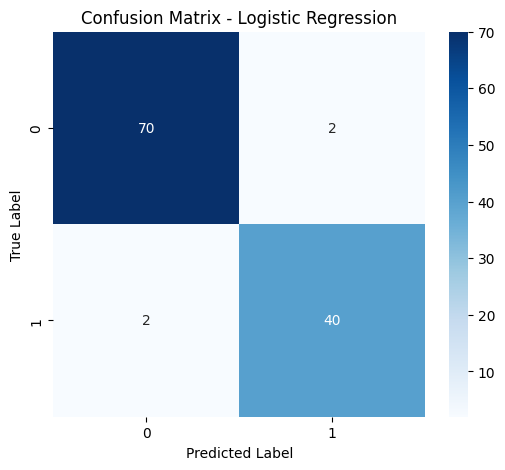

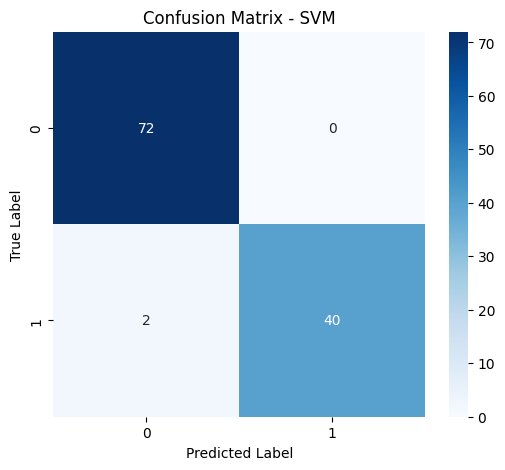

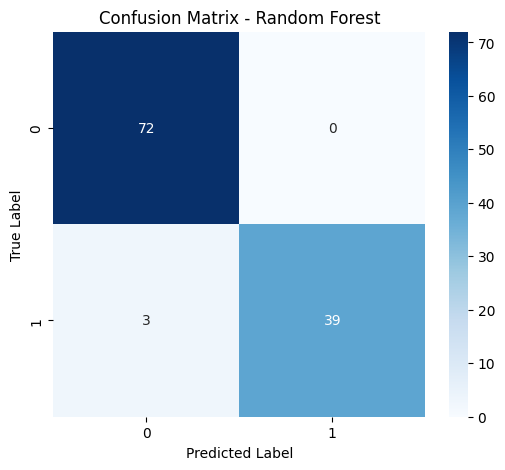

In [17]:
#%% md
## Confusion Matrix Visualization

#%%
# Confusion Matrix Heatmaps
import matplotlib.pyplot as plt
import seaborn as sns

models = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "Random Forest": y_pred_rf
}

for model_name, predictions in models.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f'Confusion Matrix - {model_name}')

    plt.xlabel('Predicted Label')

    plt.ylabel('True Label')

    plt.show()

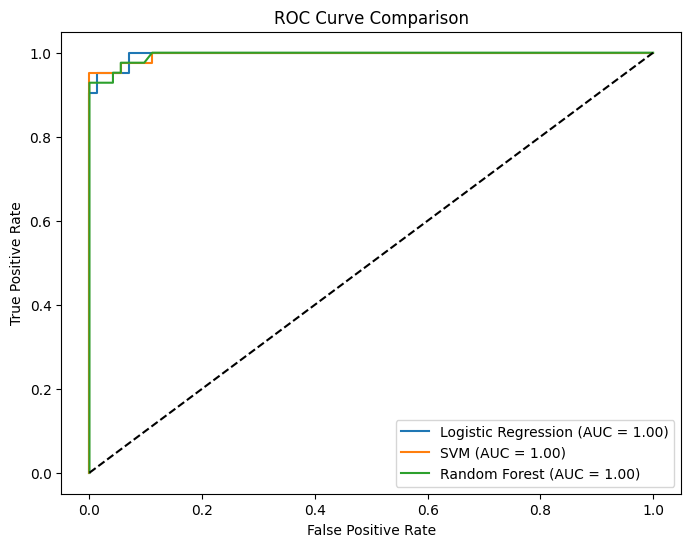

In [18]:
#%% md
## ROC Curve Comparison

#%%
# ROC Curves

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.2f})'
)

plt.plot(
    fpr_svm,
    tpr_svm,
    label=f'SVM (AUC = {roc_auc_score(y_test, y_prob_svm):.2f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.2f})'
)

plt.plot([0,1], [0,1], 'k--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.show()

In [19]:
#%% md
## Cross Validation

#%%
# Logistic Regression Cross Validation

cv_lr = cross_val_score(
    lr_model,
    X_train_selected,
    y_train_resampled,
    cv=5,
    scoring='accuracy'
)

# SVM Cross Validation

cv_svm = cross_val_score(
    svm_model,
    X_train_selected,
    y_train_resampled,
    cv=5,
    scoring='accuracy'
)

# Random Forest Cross Validation

cv_rf = cross_val_score(
    rf_model,
    X_train_selected,
    y_train_resampled,
    cv=5,
    scoring='accuracy'
)

print("Logistic Regression CV Accuracy:", cv_lr.mean())

print("SVM CV Accuracy:", cv_svm.mean())

print("Random Forest CV Accuracy:", cv_rf.mean())

Logistic Regression CV Accuracy: 0.968421052631579
SVM CV Accuracy: 0.9719298245614034
Random Forest CV Accuracy: 0.9649122807017545


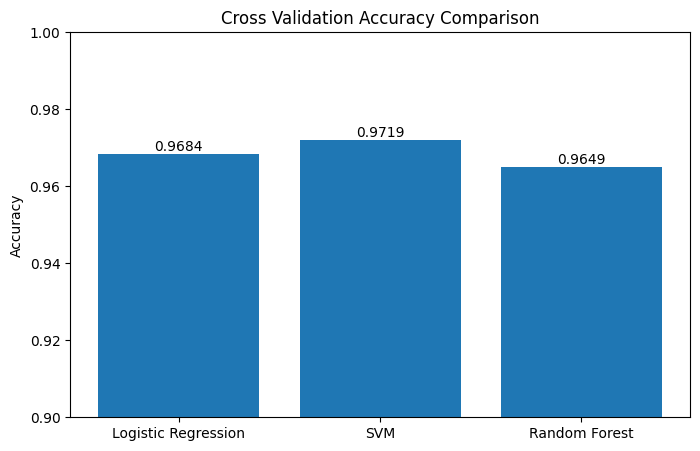

In [20]:
#%% md
## Cross Validation Accuracy Visualization

#%%
# Cross Validation Accuracy Comparison

model_names = [
    'Logistic Regression',
    'SVM',
    'Random Forest'
]

cv_scores = [
    cv_lr.mean(),
    cv_svm.mean(),
    cv_rf.mean()
]

plt.figure(figsize=(8,5))

bars = plt.bar(model_names, cv_scores)

plt.ylabel('Accuracy')

plt.title('Cross Validation Accuracy Comparison')

plt.ylim(0.9, 1.0)

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval,
        round(yval, 4),
        ha='center',
        va='bottom'
    )

plt.show()

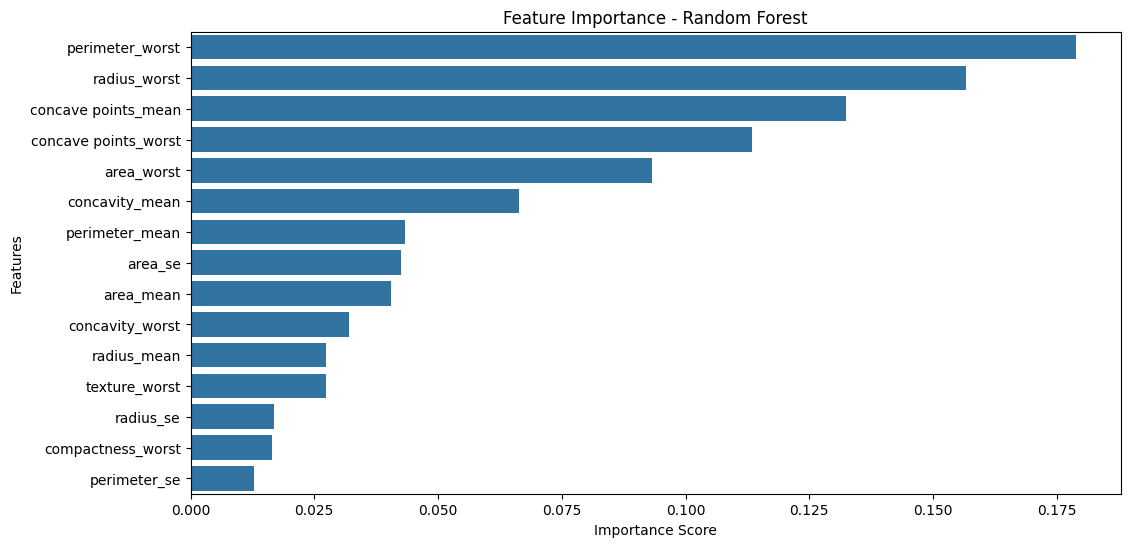

In [21]:
#%% md
## Feature Importance Visualization

#%%
# Feature Importance Plot

feature_importances = pd.Series(
    rf_model.feature_importances_,
    index=selected_feature_names
)

feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(12,6))

sns.barplot(
    x=feature_importances.values,
    y=feature_importances.index
)

plt.title('Feature Importance - Random Forest')

plt.xlabel('Importance Score')

plt.ylabel('Features')

plt.show()

In [22]:
#%% md
## Model Comparison Table

#%%
# Final Comparison Table

results_df = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'SVM',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_rf)
    ],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_rf)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_rf)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_rf)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.964912   0.952381  0.952381  0.952381  0.996032
1                  SVM  0.982456   1.000000  0.952381  0.975610  0.996032
2        Random Forest  0.973684   1.000000  0.928571  0.962963  0.995205


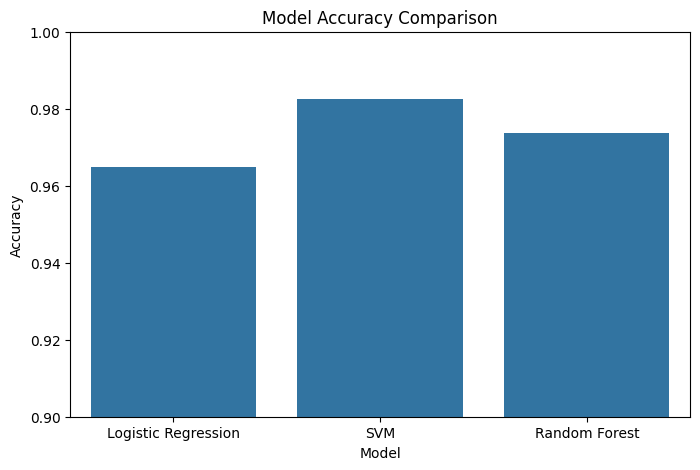

In [23]:
#%% md
## Accuracy Comparison Plot

#%%
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=results_df
)

plt.title('Model Accuracy Comparison')

plt.ylim(0.9, 1.0)

plt.show()


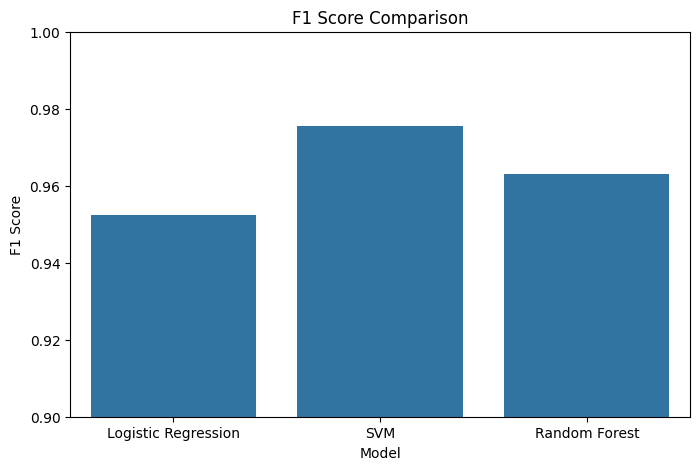

In [24]:
#%% md
## F1 Score Comparison Plot

#%%
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='F1 Score',
    data=results_df
)

plt.title('F1 Score Comparison')

plt.ylim(0.9, 1.0)

plt.show()

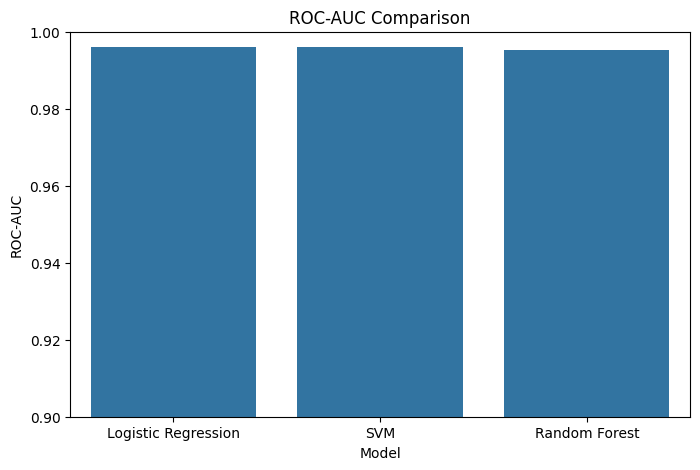

In [25]:
#%% md
## ROC-AUC Comparison Plot

#%%
plt.figure(figsize=(8,5))

sns.barplot(
    x='Model',
    y='ROC-AUC',
    data=results_df
)

plt.title('ROC-AUC Comparison')

plt.ylim(0.9, 1.0)

plt.show()



In [26]:
import joblib
import os
from google.colab import files

# Save files
joblib.dump(lr_model, "breast_cancer_model.pkl")

joblib.dump(selector, "selector.pkl")

joblib.dump(scaler, "scaler.pkl")

print("✅ Files Saved")

✅ Files Saved


In [27]:
from google.colab import files

files.download("breast_cancer_model.pkl")

files.download("selector.pkl")

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

# =====================================================
# PAGE CONFIG
# =====================================================

st.set_page_config(
    page_title="Breast Cancer Tumor Classification",
    page_icon="🩺",
    layout="wide"
)

# =====================================================
# LOAD MODEL FILES
# =====================================================

model = joblib.load("breast_cancer_model.pkl")
selector = joblib.load("selector.pkl")
scaler = joblib.load("scaler.pkl")

# =====================================================
# SIDEBAR
# =====================================================

st.sidebar.title("🩺 About Project")

st.sidebar.info(
    """
    This application predicts whether a breast tumor is:

    - Benign
    - Malignant

    using Machine Learning techniques.
    """
)

st.sidebar.success("Model Used: Logistic Regression")

# =====================================================
# TITLE
# =====================================================

st.title("🩺 Breast Cancer Tumor Classification")

st.markdown("### Upload a CSV file containing tumor feature values for prediction")

# =====================================================
# FILE UPLOADER
# =====================================================

uploaded_file = st.file_uploader("📂 Upload CSV File", type=["csv"])

# =====================================================
# INSTRUCTIONS
# =====================================================

with st.expander("📘 Instructions"):
    st.write("""
    1. Upload a CSV file
    2. System will preprocess automatically
    3. View predictions and graphs below
    """)

# =====================================================
# MAIN LOGIC
# =====================================================

if uploaded_file is not None:

    try:
        # Read file
        data = pd.read_csv(uploaded_file)

        # Drop unwanted columns
        data.drop(
            columns=["Unnamed: 32", "id", "diagnosis"],
            inplace=True,
            errors="ignore"
        )

        st.subheader("📄 Uploaded Data")
        st.dataframe(data)

        # =====================================================
        # PREPROCESSING
        # =====================================================

        scaled_data = scaler.transform(data)
        selected_data = selector.transform(scaled_data)

        # =====================================================
        # PREDICTION
        # =====================================================

        prediction = model.predict(selected_data)
        probabilities = model.predict_proba(selected_data)

        result_data = data.copy()

        result_data["Prediction"] = prediction
        result_data["Prediction"] = result_data["Prediction"].map({
            0: "Benign",
            1: "Malignant"
        })

        result_data["Benign Probability"] = probabilities[:, 0]
        result_data["Malignant Probability"] = probabilities[:, 1]

        # =====================================================
        # RESULTS
        # =====================================================

        st.subheader("🔍 Prediction Results")
        st.dataframe(result_data)

        # =====================================================
        # SUMMARY
        # =====================================================

        summary = result_data["Prediction"].value_counts()

        col1, col2 = st.columns(2)

        with col1:
            st.metric("Benign Cases", summary.get("Benign", 0))

        with col2:
            st.metric("Malignant Cases", summary.get("Malignant", 0))

        # =====================================================
        # BAR CHART (SMALL)
        # =====================================================

        st.subheader("📈 Prediction Distribution")

        fig, ax = plt.subplots(figsize=(3.5, 2.5))  # 👈 SMALL SIZE

        summary.plot(kind="bar", ax=ax)

        ax.set_xlabel("Class")
        ax.set_ylabel("Count")
        ax.set_title("Prediction Counts")

        col1, col2, col3 = st.columns(3)
        with col2:
            st.pyplot(fig, use_container_width=False)

        # =====================================================
        # PIE CHART (SMALL)
        # =====================================================

        st.subheader("🥧 Prediction Percentage")

        fig2, ax2 = plt.subplots(figsize=(3.5, 3.5))  # 👈 SMALL SIZE

        ax2.pie(
            summary,
            labels=summary.index,
            autopct='%1.1f%%'
        )

        ax2.set_title("Prediction Percentage")

        col1, col2, col3 = st.columns(3)
        with col2:
            st.pyplot(fig2, use_container_width=False)

        # =====================================================
        # DOWNLOAD
        # =====================================================

        csv = result_data.to_csv(index=False).encode("utf-8")

        st.download_button(
            label="⬇ Download Prediction Results",
            data=csv,
            file_name="prediction_results.csv",
            mime="text/csv"
        )

        st.success("✅ Prediction Completed Successfully!")

    except Exception as e:
        st.error(f"❌ Error: {e}")

Overwriting app.py


In [30]:
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
joblib
matplotlib

Writing requirements.txt


In [31]:
from google.colab import files

files.download("app.py")

files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>